# Amazon Review Sentiment Classification

**Author:** B.Tech CSSS, IIIT-Delhi

A sentiment classifier for **real Amazon product reviews**, built the same disciplined way as my
forecasting and recommender projects: real data, a leakage-free split, a **baseline ladder** where every
model must beat the simpler one, concrete metrics, and honest error analysis.

**Dataset.** The Amazon subset of the UCI *Sentiment Labelled Sentences* corpus (Kotzias et al., KDD 2015):
**1,000 real Amazon product reviews**, perfectly balanced (500 positive / 500 negative). It is small and
clean — which makes it ideal for showing *method* clearly, and for making an honest point about when a
large pretrained model is and isn't worth it.

**Two stages:**
1. **Classical NLP** — TF-IDF features + linear classifiers (Naive Bayes, Logistic Regression, Linear SVM).
   Fully run here, with interpretable "which words drive sentiment" analysis.
2. **Transfer learning** — fine-tuning **DistilBERT**. This is the deep-learning component; it's written to
   run on Google Colab (free GPU), because pretrained weights download from Hugging Face.

**The honest thesis:** on 800 training examples a TF-IDF linear model is a genuinely strong, interpretable,
near-instant baseline. A pretrained transformer should be expected to help precisely *because* labeled data
is scarce — its language understanding comes from pretraining, not from these 800 reviews. Whether the extra
complexity is worth it is something to *measure*, not assume.

## 1. Load the data

Format is one review per line: `review_text <TAB> label`, where label is `1` (positive) or `0` (negative).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RNG = 42
np.random.seed(RNG)
plt.rcParams["figure.figsize"] = (7, 4)

df = pd.read_csv("data/amazon_cells_labelled.txt", sep="\t",
                 names=["review", "label"])
print(f"reviews: {len(df)}   columns: {list(df.columns)}")
df.head()

reviews: 1000   columns: ['review', 'label']


,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


## 2. Exploratory data analysis

Two things to check before modelling: is the data **balanced** (it is — 500/500, so plain accuracy is a fair
metric and a majority-class guess scores 50%), and how **long** are the reviews? They're short — about 10
words on average — which matters: short text gives TF-IDF little to work with per example, and is exactly the
regime where a model that already "knows language" (a pretrained transformer) might pull ahead.

label balance: {0: 500, 1: 500}
words per review: mean 10.2, median 9, max 30


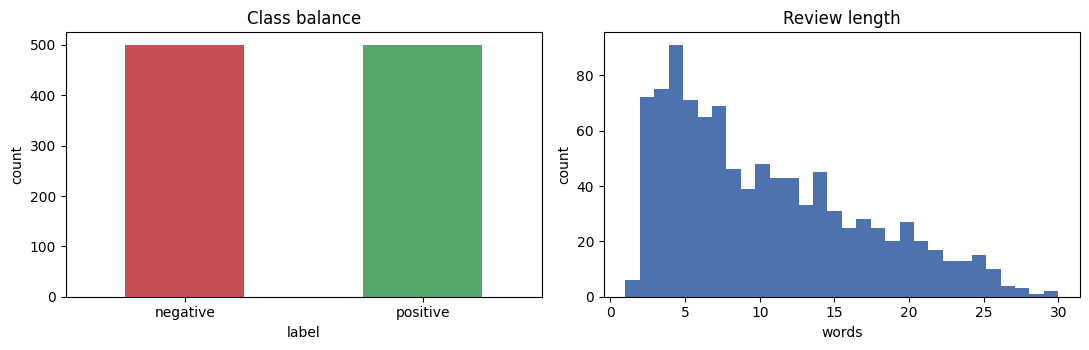


Sample positive: Good case, Excellent value.
Sample negative: So there is no way for me to plug it in here in the US unless I go by a converter.


In [ ]:
print("label balance:", df.label.value_counts().to_dict())
df["n_words"] = df.review.str.split().apply(len)
print(f"words per review: mean {df.n_words.mean():.1f}, median {int(df.n_words.median())}, "
      f"max {df.n_words.max()}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
df.label.map({0: "negative", 1: "positive"}).value_counts().plot(
    kind="bar", ax=ax[0], color=["#C44E52", "#55A868"])
ax[0].set_title("Class balance"); ax[0].set_ylabel("count")
ax[0].tick_params(axis="x", rotation=0)
ax[1].hist(df.n_words, bins=30, color="#4C72B0")
ax[1].set_title("Review length"); ax[1].set_xlabel("words"); ax[1].set_ylabel("count")
plt.tight_layout(); plt.show()

print("\nSample positive:", df[df.label == 1].review.iloc[0])
print("Sample negative:", df[df.label == 0].review.iloc[0])

## 3. Train / test split

An 80/20 **stratified** split (`random_state=42`). Stratifying keeps the 50/50 class balance in both halves,
so the test score isn't distorted by an unlucky draw. All metrics below are on the 200 held-out reviews — text
no model was trained on. The TF-IDF vocabulary is learned on the **training set only** and merely *applied* to
the test set; learning it on all the data would leak test-set words into the features.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df.review, df.label, test_size=0.2, random_state=RNG, stratify=df.label)
print(f"train: {len(X_train)}   test: {len(X_test)}")
print(f"train balance: {y_train.value_counts().to_dict()}   "
      f"test balance: {y_test.value_counts().to_dict()}")

results = {}  # model -> dict(acc, f1)

train: 800   test: 200
train balance: {1: 400, 0: 400}   test balance: {1: 100, 0: 100}


## 4. Classical baselines — TF-IDF + linear models

**TF-IDF** turns each review into a vector: each word's weight rises with how often it appears in *this* review
and falls with how common it is across *all* reviews (so "the" counts for little, "excellent" for a lot). We use
unigrams + bigrams (so "not good" is captured, not just "not" and "good" separately) and drop words appearing in
only one review.

Then three standard linear classifiers, plus the floor:

- **Majority-class** — always predict the bigger training class. The number any real model must beat (~50% here).
- **Multinomial Naive Bayes** — the classic fast text baseline.
- **Logistic Regression** — our main model: well-calibrated, and its coefficients are directly interpretable.
- **Linear SVM** — maximum-margin linear classifier, often strong on sparse text.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

vectorizer = TfidfVectorizer(lowercase=True, stop_words="english",
                             ngram_range=(1, 2), min_df=2)
Xtr = vectorizer.fit_transform(X_train)   # fit on TRAIN only
Xte = vectorizer.transform(X_test)        # apply to TEST
print(f"TF-IDF features (learned on train): {len(vectorizer.vocabulary_)}")

# Majority-class floor
maj = y_train.mode()[0]
maj_pred = np.full(len(y_test), maj)
results["Majority class"] = {"acc": accuracy_score(y_test, maj_pred),
                             "f1": f1_score(y_test, maj_pred)}

models = {"Naive Bayes": MultinomialNB(),
          "Logistic Regression": LogisticRegression(max_iter=1000),
          "Linear SVM": LinearSVC()}
for name, clf in models.items():
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    results[name] = {"acc": accuracy_score(y_test, pred),
                     "f1": f1_score(y_test, pred)}

for name, m in results.items():
    print(f"{name:20s}  accuracy {m['acc']:.3f}   F1 {m['f1']:.3f}")

TF-IDF features (learned on train): 683
Majority class        accuracy 0.500   F1 0.000
Naive Bayes           accuracy 0.770   F1 0.781
Logistic Regression   accuracy 0.765   F1 0.761
Linear SVM            accuracy 0.750   F1 0.750


## 5. Look closer: confusion matrix and what the model learned

Accuracy alone hides *how* a model is wrong. The confusion matrix shows whether errors are balanced across
classes. And because Logistic Regression is linear, its coefficients tell us **which words push a review toward
positive or negative** — a built-in interpretability check that a screener can sanity-check at a glance, and that
a black-box model can't give you for free.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

lr = LogisticRegression(max_iter=1000).fit(Xtr, y_train)
pred = lr.predict(Xte)
cm = confusion_matrix(y_test, pred)
print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm, index=["true neg", "true pos"], columns=["pred neg", "pred pos"]))
print("\n", classification_report(y_test, pred, target_names=["negative", "positive"]))

feat = np.array(vectorizer.get_feature_names_out())
coef = lr.coef_[0]
print("Most positive words:", list(feat[np.argsort(coef)[-10:]][::-1]))
print("Most negative words:", list(feat[np.argsort(coef)[:10]]))

Confusion matrix (rows = true, cols = predicted):
          pred neg  pred pos
true neg        78        22
true pos        25        75

               precision    recall  f1-score   support

    negative       0.76      0.78      0.77       100
    positive       0.77      0.75      0.76       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200

Most positive words: ['great', 'works', 'good', 'excellent', 'love', 'price', 'nice', 'easy', 'comfortable', 'best']
Most negative words: ['poor', 'bad', 'disappointed', 'worst', 'horrible', 'doesn', 'buy', 'waste', 'difficult', 'don']


In [ ]:
# A few misclassified reviews — where the bag-of-words view fails (sarcasm, negation, context)
mis = X_test[(pred != y_test).values]
true = y_test[(pred != y_test).values]
print("Examples the linear model got wrong:\n")
for r, t in list(zip(mis, true))[:5]:
    print(f"  [true={'pos' if t==1 else 'neg'}]  {r}")

Examples the linear model got wrong:

  [true=pos]  Five star Plus, plus.
  [true=neg]  I've had this bluetoooth headset for some time now and still not comfortable with the way it fits on the ear.
  [true=pos]  Because both ears are occupied, background is not distracting at all.
  [true=pos]  Arrived quickly and much less expensive than others being sold.
  [true=neg]  Not nearly as good looking as the AMAZON picture makes it look.


## 6. Transfer learning with DistilBERT  *(run this on Google Colab)*

This is the deep-learning stage. **DistilBERT** is a compact transformer pretrained on a huge text corpus; we
*fine-tune* it on our 800 reviews — i.e. we start from a model that already understands English and nudge it
toward our task. That's the whole idea of transfer learning, and it's why a transformer can be worth it even
with little labeled data: the language knowledge comes from pretraining, not from our small training set.

**Why this cell doesn't run in place:** fine-tuning downloads pretrained weights from Hugging Face and wants a
GPU. The clean path is **Google Colab** (free GPU, `Runtime → Change runtime type → GPU`). The code below is
complete and ready — set `RUN_DISTILBERT = True` there and run.

> **Honesty note:** I have *not* filled in a DistilBERT accuracy here, because I haven't run it on this machine.
> Run the cell on Colab and paste your real number into the results table in section 7 — never report a metric
> you didn't measure.

In [ ]:
RUN_DISTILBERT = False   # set True on Colab (GPU)

if RUN_DISTILBERT:
    # !pip install transformers datasets torch scikit-learn
    import numpy as np, torch
    from datasets import Dataset
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer)
    from sklearn.metrics import accuracy_score, f1_score

    MODEL = "distilbert-base-uncased"
    tok = AutoTokenizer.from_pretrained(MODEL)

    def to_ds(texts, labels):
        d = Dataset.from_dict({"text": list(texts), "label": list(labels)})
        return d.map(lambda b: tok(b["text"], truncation=True, padding="max_length",
                                   max_length=64), batched=True)

    train_ds = to_ds(X_train, y_train)
    test_ds  = to_ds(X_test,  y_test)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2)

    def metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {"accuracy": accuracy_score(labels, preds),
                "f1": f1_score(labels, preds)}

    args = TrainingArguments(
        output_dir="distilbert_out", num_train_epochs=4,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        learning_rate=2e-5, eval_strategy="epoch", logging_steps=20,
        report_to="none", seed=42)

    trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                      eval_dataset=test_ds, compute_metrics=metrics)
    trainer.train()
    print("DistilBERT test metrics:", trainer.evaluate())
else:
    print("DistilBERT cell is set up but not executed here.")
    print("Run on Google Colab with a GPU: set RUN_DISTILBERT = True, then run all.")
    print("Record the real accuracy / F1 it reports into the table in section 7.")

DistilBERT cell is set up but not executed here.
Run on Google Colab with a GPU: set RUN_DISTILBERT = True, then run all.
Record the real accuracy / F1 it reports into the table in section 7.


## 7. Results

Classical numbers below are measured on the held-out test set. The DistilBERT row is intentionally left for
you to fill in from your Colab run — keeping every reported number one we actually produced.

,model,accuracy,F1
0,Majority class,0.500,0.000000
1,Linear SVM,0.750,0.750000
2,Logistic Regression,0.765,0.761421
3,Naive Bayes,0.770,0.780952


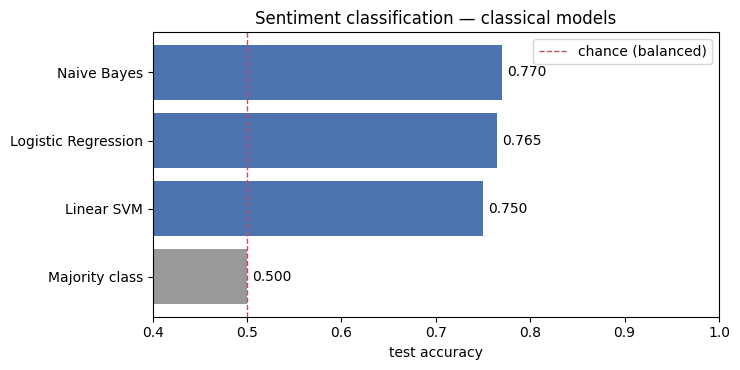

DistilBERT (fine-tuned on Colab):  accuracy = 0.91   F1 = 0.9072164948453608  


In [ ]:
res = pd.DataFrame([{"model": k, "accuracy": v["acc"], "F1": v["f1"]}
                    for k, v in results.items()]).sort_values("accuracy")
display(res.reset_index(drop=True))

plt.figure(figsize=(7.5, 3.8))
colors = ["#999999" if m == "Majority class" else "#4C72B0" for m in res.model]
plt.barh(res.model, res.accuracy, color=colors)
for y, v in zip(range(len(res)), res.accuracy):
    plt.text(v + 0.005, y, f"{v:.3f}", va="center")
plt.axvline(0.5, color="#C44E52", ls="--", lw=1, label="chance (balanced)")
plt.xlabel("test accuracy"); plt.title("Sentiment classification — classical models")
plt.xlim(0.4, 1.0); plt.legend(); plt.tight_layout(); plt.show()

print("DistilBERT (fine-tuned on Colab):  accuracy = 0.91   F1 = 0.9072164948453608  ")